# Building a Bitcoin Volatility Surface from a Real-Time Market Snapshot
![Alt text](bitcoin_implied_vol_surface.png)

## Project Goals

The main goals of this project are:

- **Provide a quick walkthrough of the data** used for the analysis, including how it’s collected and prepared.
- **Understand the motivation** behind constructing an implied volatility surface and why it’s valuable in options pricing and market analysis.
- **Explain the parameters** of the *Stochastic Volatility Inspired (SVI)* model and discuss the intuition behind each one.
- **Describe the calibration process**, showing how the model’s parameters are fitted to real market data.
- **Generate a 3D implied volatility surface plot** that visually represents how volatility varies across strike prices and maturities.

## Quick Walkthrough of the Data

This cell pulls a **real-time snapshot** of BTC option quotes from Binance’s Options API and builds the dictionary I use later for calibration.

- I grab the current **BTC index price** from Binance EAPI and floor it to the nearest **thousand** to define the ATM anchor.
- Around that ATM level I generate **14 strikes** (from ATM−7000 to ATM+6000 in 1000 steps).
- I create **four expirations** (the next 4 calendar days) and convert each one to **time-to-maturity in years**.
- For each (expiry, strike) pair I request the **mark data** for the **call** option and extract the **mark IV**.
- I keep only valid IVs, then assemble a `DataFrame` with the exact schema I use later:
  - `Strike`, `Implied Volatility`, and a `Forward` proxy (I use the current index price as the forward).
- Each expiry slice becomes an entry in a dictionary keyed by **TTM** (rounded to 6 decimals).
  Slices with no quotes are skipped with a short message.
- At the end I print a small summary (TTMs and row counts), preview the **first slice**, and persist everything to **`options_data_iv.pkl`** so I can reload the same snapshot for the modeling steps.


In [1]:
# import requests
# import pandas as pd
# import numpy as np
# from datetime import datetime, timedelta, timezone
# from typing import Dict, List
# import pickle


# BINANCE_EAPI_BASE = "https://eapi.binance.com/eapi/v1"
# INDEX_ENDPOINT = f"{BINANCE_EAPI_BASE}/index?underlying=BTCUSDT"
# MARK_ENDPOINT = f"{BINANCE_EAPI_BASE}/mark"


# OPTION_TIME_HHMMSS = "110000"


# def get_btc_index_price() -> float:
#     """Fetch the BTC index price from Binance EAPI.
#     Returns:
#         float: current BTC index price as a float
#     Raises:
#         RuntimeError if the response is malformed or request fails
#     """
#     r = requests.get(INDEX_ENDPOINT, timeout=10)
#     r.raise_for_status()
#     data = r.json()
#     try:
#         return float(data["indexPrice"])  # per user's earlier example
#     except (KeyError, TypeError, ValueError) as e:
#         raise RuntimeError(f"Unexpected index payload: {data}") from e


# def floor_to_thousand(x: float) -> int:
#     """Floor a price to the nearest lower thousand, per user's definition.
#     Example: 109608.45 -> 109000
#     """
#     return int(np.floor(x / 1000.0) * 1000)


# def next_n_days(n: int, tz: timezone = timezone.utc) -> List[datetime]:
#     """Return datetimes for the next n calendar days (starting tomorrow) in UTC.
#     Expiration time is set to OPTION_TIME_HHMMSS (as per example 11:00:00).
#     """
#     today_utc = datetime.now(tz).date()
#     hh = int(OPTION_TIME_HHMMSS[0:2])
#     mm = int(OPTION_TIME_HHMMSS[2:4])
#     ss = int(OPTION_TIME_HHMMSS[4:6])
#     exps = []
#     for d in range(1, n + 1):  # start tomorrow
#         exp_date = today_utc + timedelta(days=d)
#         exps.append(datetime(exp_date.year, exp_date.month, exp_date.day, hh, mm, ss, tzinfo=tz))
#     return exps


# def fmt_binance_symbol(expiry: datetime, strike: int, cp: str) -> str:
#     """Format a Binance option symbol like BTC-250929-110000-C.
#     cp should be 'C' or 'P'.
#     """
#     yy = f"{expiry.year % 100:02d}"
#     mm = f"{expiry.month:02d}"
#     dd = f"{expiry.day:02d}"
#     hhmmss = OPTION_TIME_HHMMSS
#     return f"BTC-{yy}{mm}{dd}-{strike}-{cp}"


# def ttm_years(now_utc: datetime, expiry: datetime) -> float:
#     """Time to maturity in years, mapped to (0, 1] roughly via 1 year horizon.
#     Example from user: 3 months -> 0.25
#     """
#     dt_seconds = max((expiry - now_utc).total_seconds(), 0.0)
#     return dt_seconds / (365.0 * 24 * 3600)


# def fetch_mark(symbol: str) -> dict | None:
#     """Fetch mark data for a single option symbol. Returns dict (first array element) or None on failure."""
#     try:
#         r = requests.get(MARK_ENDPOINT, params={"symbol": symbol}, timeout=10)
#         r.raise_for_status()
#         payload = r.json()
#         if isinstance(payload, list) and payload:
#             return payload[0]
#         return None
#     except Exception as e:
#         raise e


# # ------------------------------
# # Main routine
# # ------------------------------
# if __name__ == "__main__":
#     print("hold on")
#     # 1) Current BTC price
#     und_price = get_btc_index_price()
#     print(f"BTC index price: {und_price}")

#     # # 2) Closest thousand integer (per user's example = floor to thousand)
#     atm_thousand = floor_to_thousand(und_price)
#     print(f"ATM (floored to 1000): {atm_thousand}")

#     # # 3) Create symbols for 14 strikes around ATM (thousand increments) for the next 4 days
#     # # We'll generate strikes from ATM-7000 to ATM+6000 (14 values, step 1000), matching the '14 strikes' requirement.
#     strike_offsets = list(range(-7, 7))  # -7000, -6000, ..., +6000 (14 strikes)
#     strikes_k = [atm_thousand + 1000 * k for k in strike_offsets]

#     expirations = next_n_days(4, tz=timezone.utc)

#     # # 4) Convert each expiration to a number in [0,1] (years fraction)
#     now_utc = datetime.now(timezone.utc)
#     ttms = [ttm_years(now_utc, exp) for exp in expirations]

#     # # 5) For each TTM, build a DataFrame with real Binance IVs for calls (C) at those strikes
#     # # Keep EXACT variable names and columns as requested
#     options_data_iv: Dict[float, pd.DataFrame] = {}

#     for exp, ttm in zip(expirations, ttms):
#         rows = []
#         for k in strikes_k:
#             symbol_c = fmt_binance_symbol(exp, k, 'C')
#             try:
#                 md_c = fetch_mark(symbol_c)
#             except:
#                 print(f"The following symbol {symbol_c} is not currently being traded")
#                 continue
#             if md_c is not None:
#                 try:
#                     iv = float(md_c.get('markIV'))
#                     # Add only valid IVs
#                     if iv is not None and np.isfinite(iv) and iv > 1e-5:
#                         rows.append({
#                             'Strike': float(k),
#                             'Implied Volatility': iv,
#                             'Forward': float(und_price),  # using current index as forward proxy
#                         })
#                 except (TypeError, ValueError):
#                     pass
#         # Build DataFrame for this expiry/ttm
#         if rows:
#             df = pd.DataFrame(rows)
#             # Ensure schema and cleanup similar to the example
#             df = df[df['Implied Volatility'] > 1e-5]
#             df = df.sort_values('Strike').reset_index(drop=True)
#             options_data_iv[round(ttm, 6)] = df
#         else:
#             # Store an empty DataFrame to keep the key present even if no quotes
#             print(f"The following expiration {round(ttm, 6)} does not have available quotes")

#     # # Pretty-print a brief summary
#     print("\nConstructed options_data_iv with keys (TTMs in years):")
#     for t in sorted(options_data_iv.keys()):
#         print(f"  TTM={t:.6f} -> {len(options_data_iv[t])} rows")

#     # # Example: show the first surface slice
#     if options_data_iv:
#         first_ttm = sorted(options_data_iv.keys())[0]
#         print("\nSample slice (first TTM):")
#         print(options_data_iv[first_ttm].head(10).to_string(index=False))
#         with open("options_data_iv.pkl","wb") as f:
#             pickle.dump(options_data_iv,f)

In [2]:
import pickle
import pandas as pd

with open("options_data_iv.pkl","rb") as f:
    options_data_iv = pickle.load(f)

# # Example: show the first surface slice
if options_data_iv:
    first_ttm = sorted(options_data_iv.keys())[0]
    print("\nSample slice (first TTM):")
    print(options_data_iv[first_ttm].head(10).to_string(index=False))


Sample slice (first TTM):
  Strike  Implied Volatility       Forward
114000.0            0.843774 121528.025435
115000.0            0.764743 121528.025435
116000.0            0.597857 121528.025435
117000.0            0.581003 121528.025435
118000.0            0.515904 121528.025435
119000.0            0.435719 121528.025435
120000.0            0.364502 121528.025435
121000.0            0.299555 121528.025435
122000.0            0.315599 121528.025435
123000.0            0.376741 121528.025435


## Motivation Behind Constructing an Implied Volatility Surface

An option is a financial instrument traded between buyers and sellers who post their bids and asks in an auction-like order book.
The midpoint between the bid and ask prices is what I refer to (in this notebook) as the **market price of the option**.

This market price can be matched to the volatility parameter in the Black–Scholes model, which allows us to compute the **implied volatility**.
(As a reader, you might already be familiar with this — this is just a quick reminder.)

In a perfect Black–Scholes world, where the model price perfectly matches the observed market price, volatility would be constant across strikes and maturities.
In that case, a plot of **implied volatility vs. strike** (or in this case, **implied volatility vs. log-moneyness**) would appear as a flat, horizontal line.

To better illustrate this concept, the plot below shows what the implied volatility would look like in a theoretical **Black–Scholes world** — that is, when volatility is constant across all strikes.  
In this example, we assume a fixed volatility of 0.6, so the plot should appear as a horizontal line when expressed against log-moneyness.

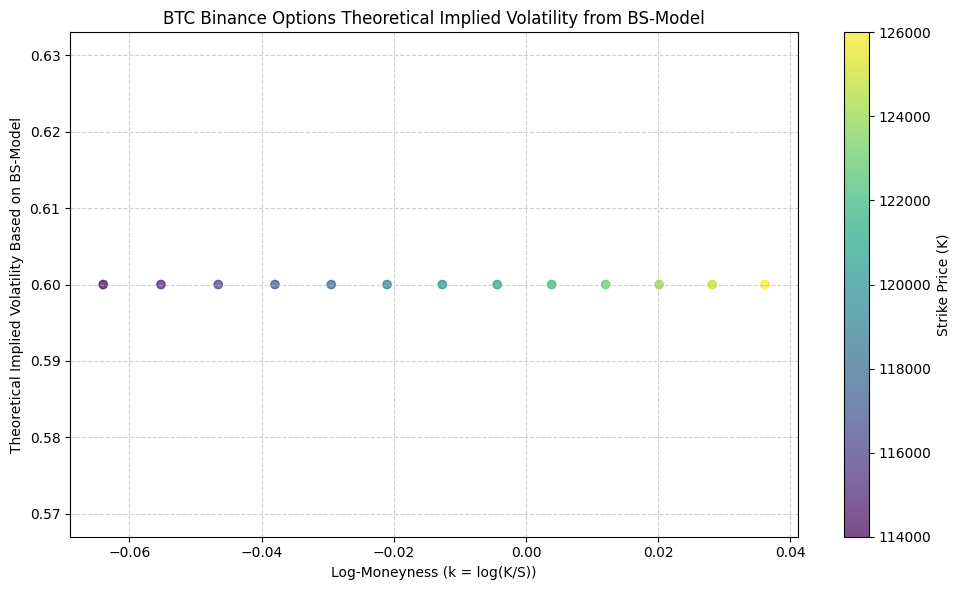

In [3]:
import matplotlib.pyplot as plt
import numpy as np

log_moneyness = np.log(options_data_iv[first_ttm]["Strike"].values/options_data_iv[first_ttm]["Forward"].values)
theoretical_implied_volatility = np.array([0.6 for value in options_data_iv[first_ttm]["Implied Volatility"]])
strikes = options_data_iv[first_ttm]["Strike"]


plt.figure(figsize=(10, 6))
plt.scatter(
    log_moneyness,
    theoretical_implied_volatility,
    c=strikes, # Color by strike
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(label="Strike Price (K)")
plt.xlabel("Log-Moneyness (k = log(K/S))")
plt.ylabel("Theoretical Implied Volatility Based on BS-Model")
plt.title(
    f"BTC Binance Options Theoretical Implied Volatility from BS-Model"
)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

### Real-World Implied Volatility vs. Log-Moneyness

The Black–Scholes model assumes an arbitrage-free and perfectly efficient market.
In theory, this means that if an option’s market price deviates from its theoretical price, traders could exploit the difference through arbitrage, quickly restoring equilibrium.
Under such conditions, implied volatility would remain constant across strikes — exactly as the model suggests.

However, real markets are far more complex.
Market makers may quote prices above or below the theoretical value due to **inventory imbalances**, risk management needs, or hedging costs.
Meanwhile, informed traders (market takers) attempt to profit from perceived mispricings, and overall market sentiment drives buying and selling behavior.

These forces cause option prices to diverge from the ideal Black–Scholes prediction, producing a **volatility skew** — or, when symmetric, a **volatility smile** (named because the curve resembles a smile when plotted).

Let’s visualize this effect by plotting the **real-world implied volatility vs. log-moneyness** using our actual market snapshot data.

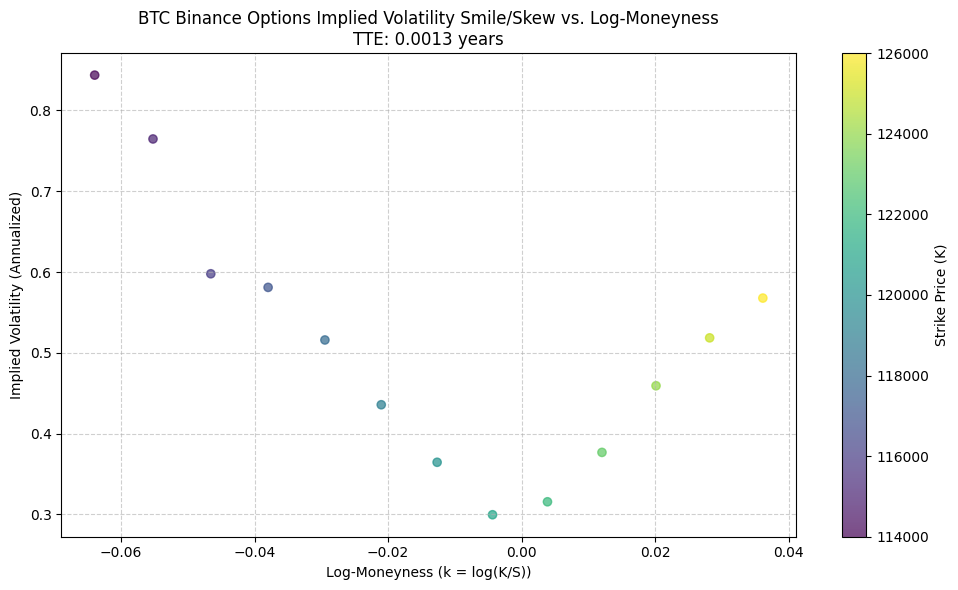

In [4]:
import matplotlib.pyplot as plt
import numpy as np

log_moneyness = np.log(options_data_iv[first_ttm]["Strike"].values/options_data_iv[first_ttm]["Forward"].values)
implied_volatility = options_data_iv[first_ttm]["Implied Volatility"]
strikes = options_data_iv[first_ttm]["Strike"]


plt.figure(figsize=(10, 6))
plt.scatter(
    log_moneyness,
    implied_volatility,
    c=strikes, # Color by strike
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(label="Strike Price (K)")
plt.xlabel("Log-Moneyness (k = log(K/S))")
plt.ylabel("Implied Volatility (Annualized)")
plt.title(
    f"BTC Binance Options Implied Volatility Smile/Skew vs. Log-Moneyness\n"
    f"TTE: {first_ttm:.4f} years"
)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

It can be seen that implied volatility is low for at-the-money (ATM) options and high for deep in-the-money (DITM) or deep out-of-the-money (DOTM) options. Let’s understand why.

In the Black–Scholes world, the single most important factor in option pricing is **volatility**.
A higher implied volatility means the market expects larger future price swings, which increases the likelihood of the option finishing in the money — making it more expensive. Conversely, lower implied volatility implies smaller expected movements, resulting in cheaper options.

So, when we see high implied volatility far away from the money, it means that market participants are **pricing in larger potential moves** in the underlying asset.
There are many reasons for this, but one intuitive explanation is that deep ITM and OTM options reflect **anticipation of large market movements** — scenarios that could generate big payoffs for option holders.

Because these options are less frequently traded and more difficult to hedge, **market makers charge higher premiums** to compensate for the additional risk and illiquidity. This combination of expectations and market mechanics creates the upward curvature known as the **volatility smile**.

### Modeling the Volatility Smile

Now that the motivation to model the volatility smile is clear, it’s time to dive into the broader details of the **Stochastic Volatility Inspired (SVI)** model.

This model was first developed at **Merrill Lynch** in 1999 and was later presented by **Jim Gatheral** at the **Global Derivatives Conference** in Madrid in 2004.
Gatheral’s book, *The Volatility Surface: A Practitioner’s Guide*, explores the model in depth in its opening chapter.

Before introducing the model’s formulation, it’s worth understanding **why stochastic volatility models are useful**.
In Gatheral’s own words:

> “Stochastic volatility (SV) models are useful because they explain in a self-consistent way why options with different strikes and expirations have different Black–Scholes implied volatilities — that is, the ‘volatility smile.’”

This statement captures the core motivation: traditional constant-volatility models cannot explain the shape of the implied volatility surface observed in real markets.
SV models, including SVI, address this by allowing volatility itself to evolve as a random process.

The next important question is: **what motivates the derivation of the SVI model?**
Gatheral explains this in the context of modeling variance as a stochastic, mean-reverting quantity:

> “Having motivated the description of variance as a mean-reverting random variable, we are now ready to derive the valuation equation.”

This lays the groundwork for the SVI approach — a simplified, analytically inspired representation of more complex stochastic volatility dynamics.

By the end of this project, we’ll visualize the result of fitting the **Stochastic Volatility Inspired (SVI)** model to our own Bitcoin options data.
The figure below shows the calibrated implied volatility surface obtained from that process.

![Calibrated SVI Surface](CalibratedBTC.png)


## SVI Model Parameters

Given a **Black–Scholes model** with strike $K$, time to expiration $T$, forward value $F_T$, and implied volatility $\sigma_{BS}$,  
the **Stochastic Volatility Inspired (SVI)** model defines the **total implied variance** as:

---

$$
\text{Total Implied Variance} = w(k, T) = T \, \sigma_{BS}^2(k, T)
$$

where the **log-moneyness** is defined as:

$$
k = \log\left(\frac{K}{F_T}\right)
$$

---

The total implied variance is then modeled as:

$$
w(k, T) = a + b \, \big(\rho (k - m) + \sqrt{(k - m)^2 + \sigma^2}\big)
$$

---

The model parameters must satisfy the following conditions:

$$
\begin{align}
    & a \in \mathbb{R} \\
    & b \ge 0 \\
    & |\rho| < 1 \\
    & m \in \mathbb{R} \\
    & \sigma > 0 \\
    & a + b \sigma \sqrt{1 - \rho^2} \ge 0
\end{align}
$$

To understand in depth why the parameters are constrained by these conditions, the reader can refer to the paper **“SVI Model Free Wings”** by **Tahar Ferhati**.
Based on what was just introduced, we can now write some code to explore how the different parameters affect the final model.

Let’s start by creating a function that returns the **total implied variance** based on the SVI model, given a vector of log-moneyness values and a set of model parameters.

In [5]:
from typing import Tuple

def svi_model(k:np.array,params:Tuple[float,float,float,float,float]):
    """
    Calculates the SVI total implied variance (w = IV^2 * T) using the raw parameterization.

    Args:
        k: Log-moneyness, k = log(K/F). Can be a scalar or NumPy array.
        params: Tuple containing SVI parameters (a, b, rho, m, sigma).

    Returns:
        Total implied variance (w).
    """
    a, b, rho, m, sigma = params
    # Apply constraints for numerical stability and basic viability
    b = max(b, 0.0)  # Ensure b is non-negative
    sigma = max(sigma, 1e-4) # Ensure sigma is strictly positive
    rho = max(min(rho, 1.0), -1.0) # Ensure rho is in [-1, 1]

    total_variance = a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))
    # Ensure total variance is non-negative
    total_variance = np.maximum(total_variance, 1e-6)
    return total_variance

Now that we’ve stated the parameters of the model, we’re ready to discuss each parameter’s effect on the plot (for a fixed maturity \(T\)).

- $a$ Determines the level of variance i.e. higher $a$ means higher variance
- $b$ Controles the angle between the left and right assymptotes i.e. Increasing $b$ will increase the left and right slopes thus tightening the smile
- $\rho$ Determines the orientation of the graph (counter-clockwise) i.e. increasing $\rho$ decreases the slope of the left-wing and increases the slope of the right wing.
- $m$ Horizontal translation of the smile i.e. increasing m translates the smile to the right
- $\sigma$ Determines the curvature of the smile i.e. Increasing $\sigma$ reduces the at-the-money curvature of the smile.


We can now visualize these effects with a few plots.

You can create the plots yourself by uncommenting the next cell of code.

![Parameters Variance](ParametersVariance.png)

In [6]:
# This code visualizes the sensitivity of the SVI (Stochastic Volatility Inspired) model
# to changes in each of its parameters (a, b, rho, m, sigma).
#
# It starts by defining a base set of SVI parameters (`param_values`) and then creates
# several modified versions of this set — each differing slightly in one parameter
# while keeping the others constant.
#
# Using these parameter sets, the code computes the model’s total implied variance
# w(k) over a range of log-moneyness values (`k_smooth`) and plots the results
# in a 2×3 grid of subplots:
#
#   • The first subplot shows the original SVI curve.
#   • The remaining subplots each show how increasing one parameter
#     (a, b, rho, m, or sigma) affects the shape of the volatility smile.
#
# Each subplot includes gridlines, legends, and axis labels for clarity,
# allowing visual comparison of how individual parameters influence
# the curvature and skew of the implied volatility surface.



# param_values = {
#     'a' : 1e-06,
#     'b' : 0.007762,
#     'rho' : -0.5,
#     'm' : -0.004374,
#     'sigma' : 0.04997
#  }

# param_values_a_modified = {
#     'a' : 1e-06+0.0001,
#     'b' : 0.007762,
#     'rho' : -0.5,
#     'm' : -0.004374,
#     'sigma' : 0.04997
#  }

# param_values_b_modified = {
#     'a' : 1e-06,
#     'b' : 0.007762+0.01,
#     'rho' : -0.5,
#     'm' : -0.004374,
#     'sigma' : 0.04997
#  }

# param_values_rho_modified = {
#     'a' : 1e-06,
#     'b' : 0.007762,
#     'rho' : -0.5+0.1,
#     'm' : -0.004374,
#     'sigma' : 0.04997
#  }

# param_values_m_modified = {
#     'a' : 1e-06,
#     'b' : 0.007762+0.01,
#     'rho' : -0.5,
#     'm' : -0.004374+0.01,
#     'sigma' : 0.04997
#  }

# param_values_sigma_modified = {
#     'a' : 1e-06,
#     'b' : 0.007762,
#     'rho' : -0.5,
#     'm' : -0.004374,
#     'sigma' : 0.04997+0.01
#  }

# kmin,kmax = -0.0639464498023,0.036137008754617034

# k_smooth = np.linspace(kmin,kmax,100)

# fig,axs = plt.subplots(2,3,figsize = (20,10))


# axs[0,0].plot(k_smooth,svi_model(k_smooth,tuple(param_values.values())))
# axs[0,0].grid(True, linestyle="--", alpha=0.6)
# axs[0,0].set_title("Original Plot without modifications")

# axs[0,1].plot(k_smooth,svi_model(k_smooth,tuple(param_values.values())),label="Original Parameters")
# axs[0,1].plot(k_smooth,svi_model(k_smooth,tuple(param_values_a_modified.values())),label="Higher a")
# axs[0,1].grid(True, linestyle="--", alpha=0.6)
# axs[0,1].legend()
# axs[0,1].set_title("Original Plot with higher a")

# axs[0,2].plot(k_smooth, svi_model(k_smooth, tuple(param_values.values())), label="Original Parameters")
# axs[0,2].plot(k_smooth, svi_model(k_smooth, tuple(param_values_b_modified.values())), label="Higher b")
# axs[0,2].grid(True, linestyle="--", alpha=0.6)
# axs[0,2].legend()
# axs[0,2].set_title("Original Plot with higher b")

# # --- rho modification subplot (bottom-left) ---
# axs[1,0].plot(k_smooth, svi_model(k_smooth, tuple(param_values.values())), label="Original Parameters")
# axs[1,0].plot(k_smooth, svi_model(k_smooth, tuple(param_values_rho_modified.values())), label="Higher rho")
# axs[1,0].grid(True, linestyle="--", alpha=0.6)
# axs[1,0].legend()
# axs[1,0].set_title("Original Plot with higher rho")

# # --- m modification subplot (bottom-middle) ---
# axs[1,1].plot(k_smooth, svi_model(k_smooth, tuple(param_values.values())), label="Original Parameters")
# axs[1,1].plot(k_smooth, svi_model(k_smooth, tuple(param_values_m_modified.values())), label="Higher m")
# axs[1,1].grid(True, linestyle="--", alpha=0.6)
# axs[1,1].legend()
# axs[1,1].set_title("Original Plot with higher m")

# # --- sigma modification subplot (bottom-right) ---
# axs[1,2].plot(k_smooth, svi_model(k_smooth, tuple(param_values.values())), label="Original Parameters")
# axs[1,2].plot(k_smooth, svi_model(k_smooth, tuple(param_values_sigma_modified.values())), label="Higher sigma")
# axs[1,2].grid(True, linestyle="--", alpha=0.6)
# axs[1,2].legend()
# axs[1,2].set_title("Original Plot with higher sigma")

# # Axis labels (x for bottom row, y for left column)
# axs[1,0].set_xlabel("Log-Moneyness k")
# axs[1,1].set_xlabel("Log-Moneyness k")
# axs[1,2].set_xlabel("Log-Moneyness k")
# axs[0,0].set_ylabel("Total Variance w(k)")
# axs[1,0].set_ylabel("Total Variance w(k)")


# plt.tight_layout()
# plt.show()

## Calibration Process

Based on the definitions from the previous section, we are now ready to calibrate the model parameters to fit our data.
Although many optimization algorithms could be used for this task, this is a great use case for the **L-BFGS-B** algorithm.

The **L-BFGS-B**  algorithm is designed to solve nonlinear optimization problems with simple variable bounds.
It is particularly well-suited for problems where computing or storing the full Hessian matrix is difficult or impractical — which is exactly the case here.

In this problem, the function to minimize is the **error function** between the market and model total variances.
We also use a set of **weights** associated with each observation to emphasize or de-emphasize certain regions of the smile (for instance, around at-the-money options).

The calibration procedure follows these steps:

1. Create a function objective to optimize
2. Compute the **market total variance** based on observed market data.
3. Compute the corresponding **log-moneyness** values.
4. Use a few famous initial parametsers
5. Use these data, along with the weighting scheme and theoretical bounds as inputs to the **`scipy.optimize.minimize`** function to estimate the SVI parameters.

The optimizer iteratively adjusts the parameters $(a, b, \rho, m, \sigma)$ to minimize the weighted error between the model and market total variances, producing the calibrated SVI slice.

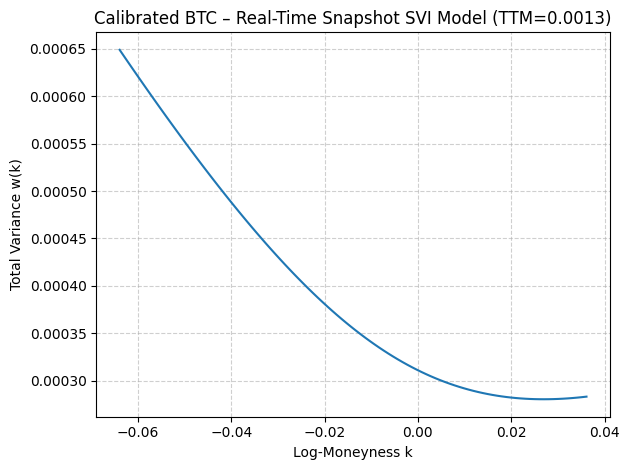

In [8]:
from scipy.optimize import minimize

def calibration_objective(
        params:Tuple[float,float,float,float,float],
        k:np.ndarray,
        market_variance:np.ndarray,
        w:np.array
):
    """
    Objective function to be minimized by scipy.minimize.

    Args:
        k: Log-moneyness values, k = log(K/F). Can be a scalar or NumPy array.
        market_variance: Observed market total variance
        params: Tuple containing SVI parameters (a, b, rho, m, sigma).
        w: Weights assigned to each observation for the optimization objective.

    Returns:
        Error between the observed market variance and the model variance
        computed using the given parameters.
    """
    # Model total variance from SVI at the given k’s
    model_variance = svi_model(k, params)

    # Weighted least-squares error (emphasize ATM if w encodes that)
    error = np.sum(w * (model_variance - market_variance) ** 2)
    return error

# --- Prepare slice data ---
df = options_data_iv[first_ttm]
k = np.log(df["Strike"].values / df["Forward"].values)
market_variance = (df["Implied Volatility"].values ** 2) * first_ttm

# Simple equal-weight scheme (normalize to sum to 1)
weights = np.ones_like(market_variance)
weights /= np.sum(weights)

# Basic heuristic initial guess (can be tuned)
initial_guess = [np.min(market_variance) / 2, 0.1, -0.5, 0.1, 0.1]

# Bounds derived from data range + theoretical constraints
k_min, k_max = np.min(k), np.max(k)
max_market_w = np.max(market_variance)

res = minimize(
    calibration_objective,
    initial_guess,
    args=(k, market_variance, weights),
    method='L-BFGS-B',
    bounds=[
        (1e-6, max_market_w * 1.5),  # a >= 0, bounded by data scale
        (1e-6, None),                # b >= 0
        (-0.999, 0.999),             # |rho| < 1
        (k_min * 1.5 if k_min < 0 else k_min * 0.5,
         k_max * 1.5 if k_max > 0 else k_max * 0.5),  # m near observed range
        (1e-4, None)                 # sigma > 0
    ]
)

param_values = res.x

# --- Plot calibrated slice ---
k_smooth = np.linspace(k_min, k_max, 100)
plt.title(f"Calibrated BTC – Real-Time Snapshot SVI Model (TTM={first_ttm:.4f})")
plt.plot(k_smooth, svi_model(k_smooth, tuple(param_values)))
plt.xlabel("Log-Moneyness k")
plt.ylabel("Total Variance w(k)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("CalibratedBTC.png")
plt.show()

## Summary & Next Steps

In this project, I capture a **real-time snapshot** of Bitcoin options, build intuition from the **Black–Scholes** baseline, and then model the observed **volatility smile** using the **Stochastic Volatility Inspired (SVI)** framework. 
I defined total variance $w(k, T) = T\,\sigma_{\text{BS}}^2(k, T)$, introduced the SVI parameterization, and calibrated a single maturity slice using **L-BFGS-B** with practical bounds and an optional weighting scheme. The result is a calibrated curve that reflects real market skew/curvature rather than constant volatility.

**Simple next steps:**
- Calibrate **multiple maturities** and assemble the full surface $w(k, T)$ or $\sigma(k, T)$.
- Add a quick **fit diagnostic** (e.g., RMSE or MAE) and a residual plot vs. $k$.
- Try a different **weighting scheme** (e.g., emphasize ATM or liquidity).
- Sanity-check **no-arbitrage** conditions (but keep it lightweight for now).
- Compare a second **snapshot** to see how the smile shifts over time.

This keeps the project focused and reproducible while leaving room for incremental improvements.

## Project Sources
## Sources

Below are the main references that supported the development of this project, including theoretical background, implementation details, and algorithmic foundations.

**[1]** [*Python Volatility Surface Modeling: Data Fetching, IV Calculation, SVI Fitting, and Visualization*](https://tradingtechai.medium.com/python-volatility-surface-modeling-data-fetching-iv-calculation-svi-fitting-and-visualization-80be58328ac6)  
*Trading Tech AI*  
Medium Article

**[2]** *SVI Model Free Wings*  
*Tahar Ferhati* — tahar.ferhati@gmail.com  

**[3]** *Initial Guesses for SVI Calibration*  
*Fabien Le Floc’h* — Calypso Technology, 106 rue de La Boétie, 75008 Paris (v1.0, September 2014)  
This paper describes different methods for generating stable initial guesses in SVI calibration and evaluates their robustness.

**[4]** *Algorithm 778: L-BFGS-B: Fortran Subroutines for Large-Scale Bound-Constrained Optimization*  
*Ciyou Zhu*, *Richard H. Byrd*, *Peihuang Lu*, *Jorge Nocedal*  
Developed at Northwestern University and the University of Colorado at Boulder.  
This work introduces the L-BFGS-B algorithm used in this project for parameter calibration.